In [26]:
import numpy as np
import pandas as pd

In [27]:
df = pd.read_csv(r"C:\Users\AnuBa\Downloads\spam.csv", encoding='latin1')



In [28]:
df.sample(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2670,ham,Yes. They replied my mail. I'm going to the ma...,NaN,NaN,NaN
76,ham,Thats cool. i am a gentleman and will treat yo...,NaN,NaN,NaN
1082,ham,Send to someone else :-),NaN,NaN,NaN
1022,ham,We still on for tonight?,NaN,NaN,NaN
1978,ham,No I'm in the same boat. Still here at my moms...,NaN,NaN,NaN
4513,ham,"Sure, whenever you show the fuck up &gt;:(",NaN,NaN,NaN
2765,ham,and picking them up from various points,NaN,NaN,NaN
408,ham,Headin towards busetop,NaN,NaN,NaN
1043,ham,Mmm thats better now i got a roast down me! iå...,NaN,NaN,NaN
1327,spam,Ur balance is now å£500. Ur next question is: ...,NaN,NaN,NaN


In [29]:
df.shape

(5572, 5)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [31]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], errors='ignore', inplace=True)


In [32]:
df.sample(10)

,v1,v2
3824,ham,Hi. I'm always online on yahoo and would like ...
3729,ham,"I guess you could be as good an excuse as any,..."
3209,ham,"She said,'' do u mind if I go into the bedroom..."
2174,ham,See? I thought it all through
2943,spam,We currently have a message awaiting your coll...
990,ham,26th OF JULY
4291,ham,G.W.R
3746,ham,ÌÏ neva tell me how i noe... I'm not at home i...
4735,ham,"Not for possession, especially not first offense"
3640,spam,You can stop further club tones by replying \S...


In [33]:
df.rename(columns={'v1':'target',"v2":"text"},inplace=True)
df.sample(5)

,target,text
3202,ham,Haha... Yup hopefully we will lose a few kg b...
5461,ham,Ok i thk i got it. Then u wan me 2 come now or...
4550,ham,Great. Have a safe trip. Dont panic surrender ...
5047,ham,Yeah so basically any time next week you can g...
1497,ham,I'm putting it on now. It should be ready for ...


In [34]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [35]:
encoder.fit_transform(df["target"])

array([0, 0, 1, ..., 0, 0, 0])

In [36]:
df["target"]=encoder.fit_transform(df["target"])

In [37]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [38]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [39]:
df.duplicated().sum()

403

In [40]:
df.drop_duplicates(keep='first')

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [41]:
df = df.drop_duplicates(keep='first')

In [42]:
df.duplicated().sum()

0

In [43]:
df.shape

(5169, 2)

In [44]:
#2 EDA

In [45]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [46]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x1cdc7f8ec00>,
 [Text(-1.0144997251399075, 0.4251944351600247, 'ham'),
  Text(1.014499764949479, -0.4251943401757036, 'spam')],
 [Text(-0.5533634864399495, 0.23192423736001344, '87.37'),
  Text(0.5533635081542612, -0.23192418555038377, '12.63')])

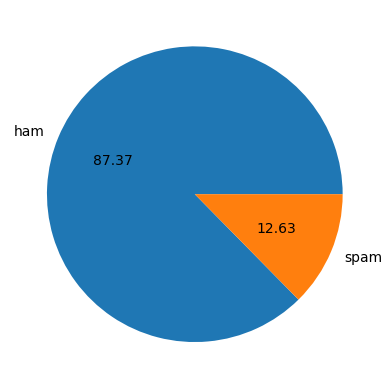

In [47]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=["ham", "spam"],autopct="%0.2f")

In [48]:
#data is imbalanced

In [49]:
!pip install nltk
import nltk



In [50]:

nltk.download('punkt') 
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\AnuBa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\AnuBa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [52]:
df["text"].apply(len)

0       111
1        29
2       155
3        49
4        61
       ... 
5567    161
5568     37
5569     57
5570    125
5571     26
Name: text, Length: 5169, dtype: int64

In [53]:
df['num_characters'] = df["text"].apply(len)

In [54]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [55]:
df["text"].apply(lambda x:len(nltk.word_tokenize(x))) #breaks the words into numbers and the len counts the number

0       24
1        8
2       37
3       13
4       15
        ..
5567    35
5568     9
5569    15
5570    27
5571     7
Name: text, Length: 5169, dtype: int64

In [56]:
df['num_words']=df["text"].apply(lambda x:len(nltk.word_tokenize(x)))

In [57]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [58]:
df['num_sentences']=df["text"].apply(lambda x:len(nltk.sent_tokenize(x)))

In [59]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [60]:
df[["num_characters","num_words","num_sentences"]].describe() #describes whats going on 

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [61]:
df[df["target"] ==0][["num_characters","num_words","num_sentences"]].describe() #for ham

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [62]:
df[df["target"] ==1][["num_characters","num_words","num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [63]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

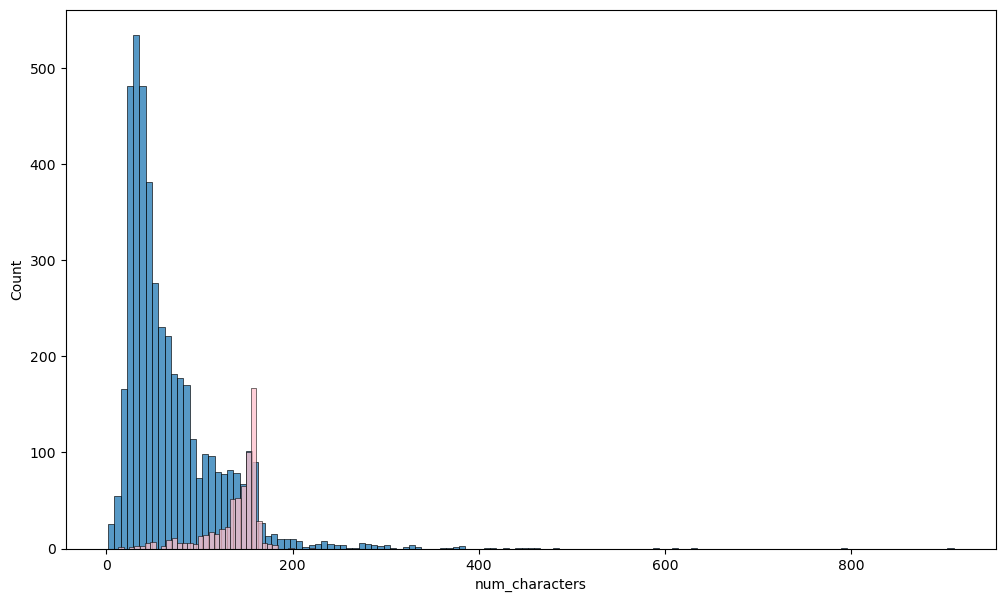

In [64]:
plt.figure(figsize=(12,7)) #3
sns.histplot(df[df["target"] == 0]["num_characters"]) #1
sns.histplot(df[df["target"] == 1]["num_characters"],color="pink") #2

In [65]:
#Ham messages are shorter and simpler.

#Spam messages tend to be longer, often containing promotional or alert text.

<Axes: xlabel='num_words', ylabel='Count'>

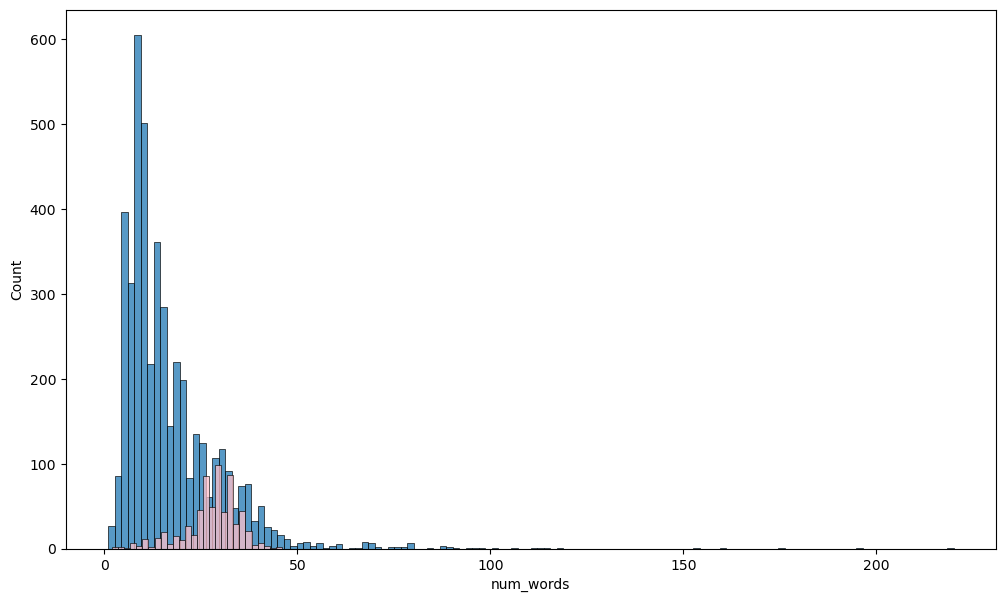

In [66]:
plt.figure(figsize=(12,7)) #3
sns.histplot(df[df["target"] == 0]["num_words"]) #1
sns.histplot(df[df["target"] == 1]["num_words"],color="pink") #2

In [ ]:
#more words in spam and less words in ham

<Axes: xlabel='num_sentences', ylabel='Count'>

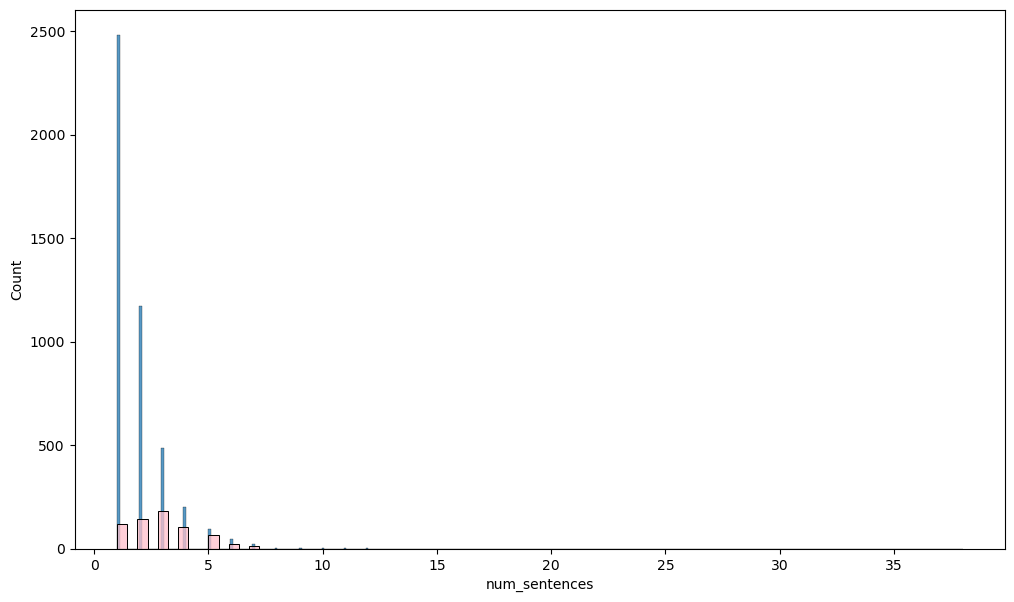

In [67]:
plt.figure(figsize=(12,7)) #3
sns.histplot(df[df["target"] == 0]["num_sentences"]) #1
sns.histplot(df[df["target"] == 1]["num_sentences"],color="pink") #2

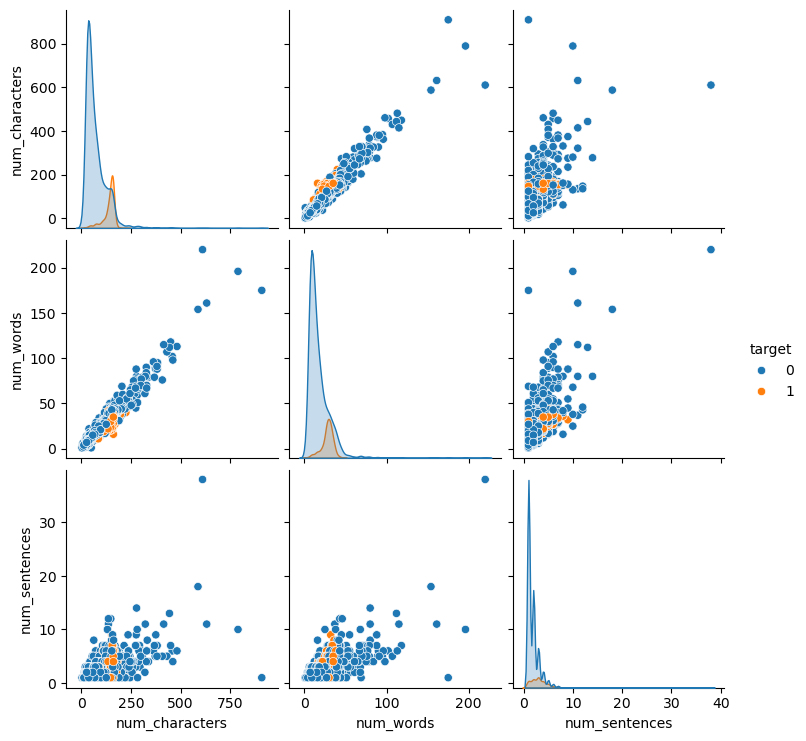

In [68]:
sns.pairplot(df,hue="target")

<Axes: >

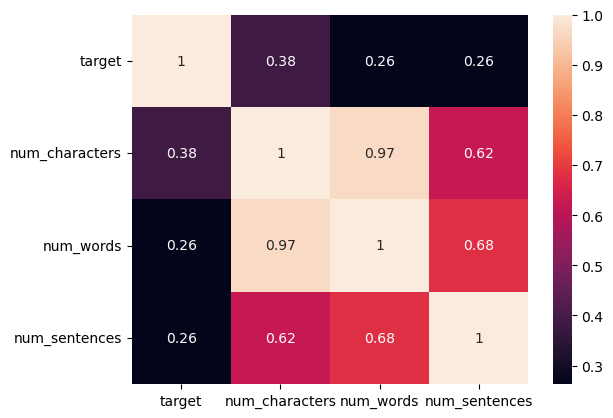

In [69]:
df_numeric = df.select_dtypes(include=['number'])
sns.heatmap(df_numeric.corr(), annot=True,)

In [ ]:
#data preprocessing
#1.lower case 
#2. tokenization 3.removing special characters 4.removing stop words and punctuation
#5.stemming


In [70]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')

# Initialize the stemmer
ps = PorterStemmer()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\AnuBa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AnuBa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [71]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
            
    return " ".join(y)

In [74]:
transform_text("Nah I don't think he goes to usf, he lives around here though")

'nah think goe usf live around though'

In [73]:
df['text'][4]

"Nah I don't think he goes to usf, he lives around here though"

In [75]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('learning')

'learn'

In [76]:
df['transformed_text'] = df['text'].apply(transform_text)

In [79]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [ ]:
#we use wordcloud, words ko bda karke dikhayega

In [80]:
!pip install WordCloud

In [81]:
from wordcloud import WordCloud
wc = WordCloud(width=1000,height=1000,min_font_size=10,background_color="beige")

In [82]:
spam_wc = wc.generate(df[df['target'] == 1]["transformed_text"].str.cat(sep=" "))

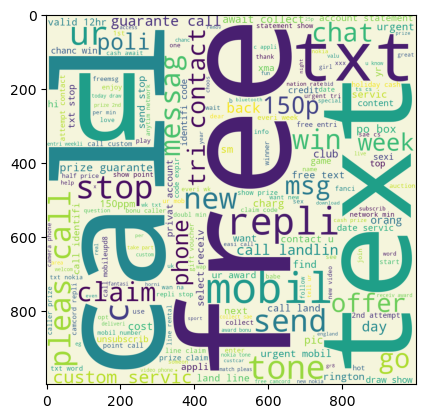

In [83]:
plt.imshow(spam_wc)

In [ ]:
#shows the word mostly used in spam messages 

In [84]:
ham_wc = wc.generate(df[df['target'] == 0]["transformed_text"].str.cat(sep=" "))

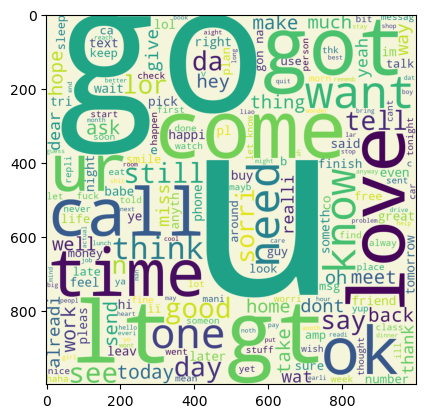

In [90]:
plt.imshow(ham_wc)

In [ ]:
#top 30 words used in both ham and spam

In [85]:
spam_corpus = []
for msg in df[df["target"] == 1]["transformed_text"].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [86]:
len(spam_corpus)

9939

C:\Users\AnuBa\AppData\Local\Temp\ipykernel_18784\2675623455.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Count', data=word_freq, palette='viridis')


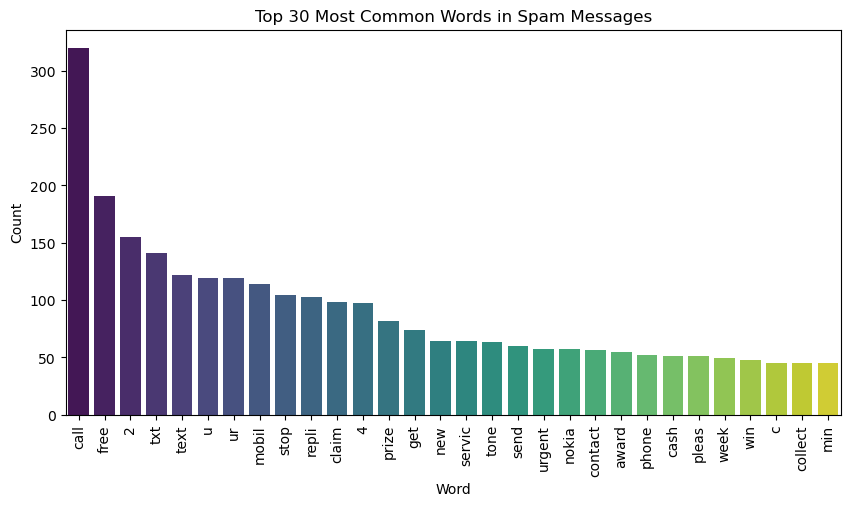

In [88]:
from collections import Counter


# Create a frequency DataFrame of top 30 words
word_freq = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['Word', 'Count'])

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x='Word', y='Count', data=word_freq, palette='viridis')
plt.xticks(rotation='vertical')
plt.title("Top 30 Most Common Words in Spam Messages")
plt.show()


C:\Users\AnuBa\AppData\Local\Temp\ipykernel_18784\2023852566.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Count', data=word_freq, palette='viridis')


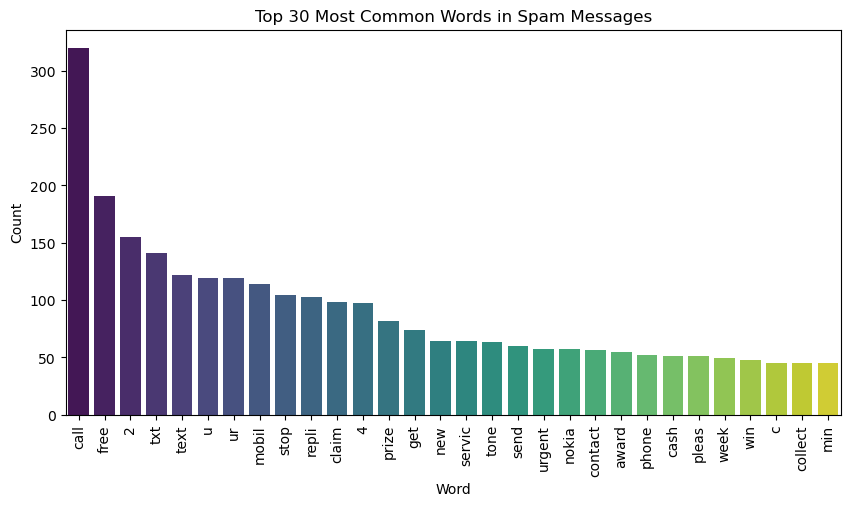

In [89]:
word_freq = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['Word', 'Count'])
plt.figure(figsize=(10,5))
sns.barplot(x='Word', y='Count', data=word_freq, palette='viridis')
plt.xticks(rotation='vertical')
plt.title("Top 30 Most Common Words in Spam Messages")
plt.show()


In [90]:
ham_corpus = []
for msg in df[df["target"] == 0]["transformed_text"].tolist():
    for word in msg.split():
        ham_corpus.append(word)



In [91]:
len(ham_corpus)

35404

C:\Users\AnuBa\AppData\Local\Temp\ipykernel_18784\4227917473.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Count', data=word_freq, palette='viridis')


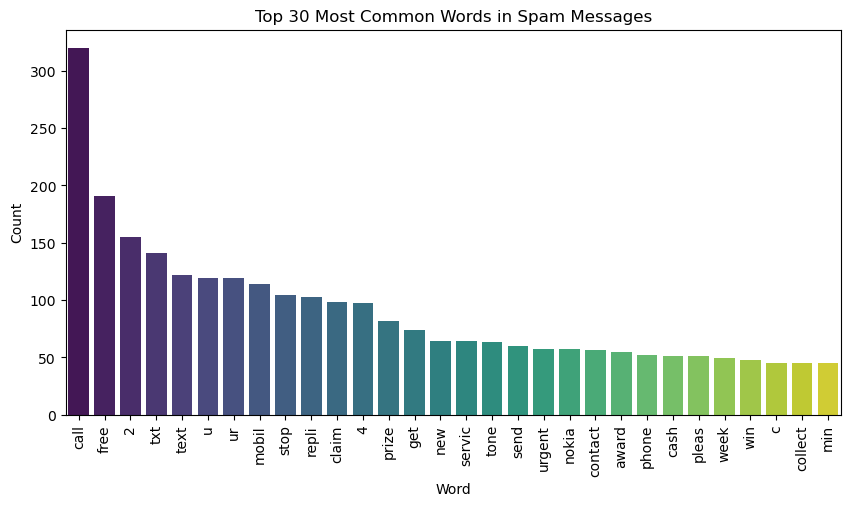

In [92]:
from collections import Counter

plt.figure(figsize=(10,5))
sns.barplot(x='Word', y='Count', data=word_freq, palette='viridis')
plt.xticks(rotation='vertical')
plt.title("Top 30 Most Common Words in Spam Messages")
plt.show()


In [93]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [ ]:
#4 model building

In [94]:
import sklearn
print(sklearn.__version__)


1.5.1


In [95]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

cv = CountVectorizer()
tfidf = TfidfVectorizer()


In [107]:
X = tfidf.fit_transform(df["transformed_text"]).toarray()

In [108]:
X.shape

(5169, 6708)

In [109]:
 y = df["target"].values

In [110]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [111]:
from sklearn.model_selection import train_test_split

In [112]:
X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size=0.2,random_state=2)

In [113]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [114]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [105]:
mnb.fit(X_train,y_train)
y_pred1 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.9642166344294004
[[871  25]
 [ 12 126]]
0.8344370860927153


In [115]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9593810444874274
[[896   0]
 [ 42  96]]
1.0


In [106]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


In [134]:
models = ['MultinomialNB', 'BernoulliNB']
accuracies = [accuracy_score(y_test, y_pred2), accuracy_score(y_test, y_pred3)]
precisions = [precision_score(y_test, y_pred2), precision_score(y_test, y_pred3)]

import pandas as pd
results = pd.DataFrame({'Model': models, 'Accuracy': accuracies, 'Precision': precisions})
print(results)


           Model  Accuracy  Precision
0  MultinomialNB  0.959381   1.000000
1    BernoulliNB  0.970019   0.973451


In [135]:
bnb.fit(X_train, y_train)


BernoulliNB()

In [ ]:
def predict_sms():
    while True:
        msg = input("Enter SMS (or 'exit' to quit): ")
        if msg.lower() == 'exit':
            break
        transformed_msg = transform_text(msg)
        vector_input = tfidf.transform([transformed_msg])
        result = bnb.predict(vector_input)[0]
        print("Spam message detected" if result == 1 else "Not a spam message")

predict_sms()


Enter SMS (or 'exit' to quit):  i had fun learning python in today's class, how about you?


Not a spam message


Enter SMS (or 'exit' to quit):  TEXT 1 TO WIN A FREE IPHONE!!


Not a spam message


Enter SMS (or 'exit' to quit):  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entr...


Spam message detected
